In [208]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [209]:
import pandas as pd

In [210]:
ROOT = "./"

training_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_training-set.csv")
testing_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_testing-set.csv")

print(training_set.head())
print(testing_set.head())


   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

In [211]:
# Preprocessing the data

training_set_processed = training_set.copy()
testing_set_processed = testing_set.copy()

training_missing_values = training_set_processed.isnull().sum().sum()
testing_missing_values = testing_set_processed.isnull().sum().sum()
print(f"Number of missing values in training set: {training_missing_values}")
print(f"Number of missing values in testing set: {testing_missing_values}")

training_set_processed = training_set_processed.dropna()
testing_set_processed = testing_set_processed.dropna()
print(f"Number of missing values after dropping: {training_set_processed.isnull().sum().sum()}")
print(f"Number of missing values after dropping: {testing_set_processed.isnull().sum().sum()}")

Number of missing values in training set: 0
Number of missing values in testing set: 0
Number of missing values after dropping: 0
Number of missing values after dropping: 0


# 1. Comparative Security Modeling

## 1.1 Binary Intrusion Detection

In [212]:
X_train_bin = training_set_processed.drop(columns=["attack_cat", "label"])
y_train_bin = training_set_processed["label"]

X_test_bin = testing_set_processed.drop(columns=["attack_cat", "label"])
y_test_bin = testing_set_processed["label"]

In [213]:
# One hot encoding for all categorical features
X_train_bin = pd.get_dummies(X_train_bin)
X_test_bin = pd.get_dummies(X_test_bin)

print(X_train_bin.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_bin = X_test_bin.reindex(columns=X_train_bin.columns, fill_value=False)

print(X_train_bin.head())
print(X_test_bin.head())

   id       dur  spkts  dpkts  sbytes  dbytes       rate  sttl  dttl  \
0   1  0.121478      6      4     258     172  74.087490   252   254   
1   2  0.649902     14     38     734   42014  78.473372    62   252   
2   3  1.623129      8     16     364   13186  14.170161    62   252   
3   4  1.681642     12     12     628     770  13.677108    62   252   
4   5  0.449454     10      6     534     268  33.373826   254   252   

          sload  ...  service_ssl  state_CON  state_ECO  state_FIN  state_INT  \
0  14158.942380  ...        False      False      False       True      False   
1   8395.112305  ...        False      False      False       True      False   
2   1572.271851  ...        False      False      False       True      False   
3   2740.178955  ...        False      False      False       True      False   
4   8561.499023  ...        False      False      False       True      False   

   state_PAR  state_REQ  state_RST  state_URN  state_no  
0      False      Fals

### Tuning XGBClassifier

In [214]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

In [ ]:
params = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'scale_pos_weight': [1, 1.5, 2]
}

start_time = time.time()

bin_gs = GridSearchCV(XGBClassifier(n_jobs=-1, objective='binary:logistic', eval_metric='auc'), params, n_jobs=-1, cv=3, scoring='recall', verbose=3)
bin_gs.fit(X_train_bin, y_train_bin)

end_time = time.time()

print('Best score:', bin_gs.best_score_)
print('Best params:', bin_gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best score: 0.6855455002513825
Best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'scale_pos_weight': 1.5}
Time taken for grid search: 7.7 minutes


### Predictions

In [ ]:
### https://xgboost.readthedocs.io/en/release_3.2.0/get_started.html

from xgboost import XGBClassifier

# create model instance
bin_bst = XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.01, scale_pos_weight=1.5, objective='binary:logistic', eval_metric='auc')
# fit model
bin_bst.fit(X_train_bin, y_train_bin)
# make predictions
bin_preds = bin_bst.predict(X_test_bin)
#y_proba = bin_bst.predict_proba(X_test_bin)[:, 1]

In [227]:
# ### Try to find best threshold for binary classification
# import numpy as np
# from sklearn.metrics import f1_score

# best_t = 0
# best_f1 = 0

# for t in np.linspace(0.1, 1, 100):
#     preds = (y_proba > t).astype(int)
#     f1 = f1_score(y_test_bin, preds)
#     print(t, f1)
    
#     if f1 > best_f1:
#         best_f1 = f1
#         best_t = t

# print("Best threshold:", best_t)

In [228]:
# preds = (y_proba > 0.24)
# print(preds)

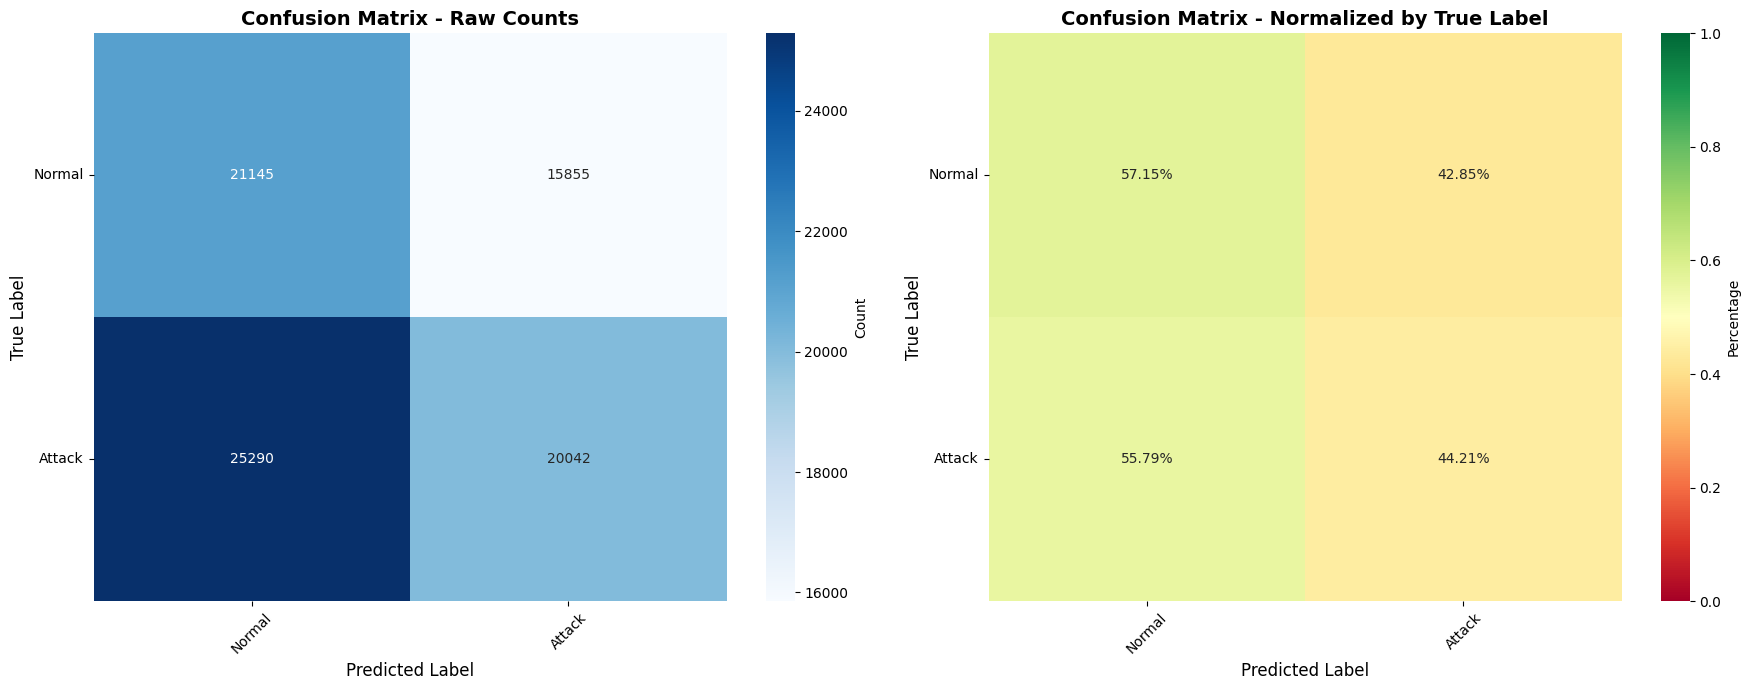

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
bin_target_names = ['Normal', 'Attack']

bin_cm = confusion_matrix(y_test_bin, bin_preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(bin_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=bin_target_names, yticklabels=bin_target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
bin_cm_normalized = bin_cm.astype('float') / bin_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(bin_cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=bin_target_names, yticklabels=bin_target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# Precision, Recall, F1-score
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

bin_target_names = ['Normal', 'Attack']

## Performance metrics
print("Accuracy:", accuracy_score(y_test_bin, bin_preds))
print("\nClassification Report:\n",
      classification_report(y_test_bin, bin_preds, target_names=bin_target_names))

Accuracy: 0.5002550648593499

Classification Report:
               precision    recall  f1-score   support

      Normal       0.46      0.57      0.51     37000
      Attack       0.56      0.44      0.49     45332

    accuracy                           0.50     82332
   macro avg       0.51      0.51      0.50     82332
weighted avg       0.51      0.50      0.50     82332



In [ ]:
# False Positive Rate (FPR) and False Negative Rate (FNR)

tn, fp, fn, tp = bin_cm.ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"False Positive Rate (FPR): {fpr:.2f}")
print(f"False Negative Rate (FNR): {fnr:.2f}")

False Positive Rate (FPR): 0.43
False Negative Rate (FNR): 0.56


## 1.2 Class Attack Category Classification

In [169]:
X_train_class = training_set.drop(columns=["attack_cat", "label"])
y_train_class = training_set["attack_cat"]

X_test_class = testing_set.drop(columns=["attack_cat", "label"])
y_test_class = testing_set["attack_cat"]

attack_classes_names = y_train_class.unique()
print(attack_classes_names)

# Replace attack category names with numeric labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_class_encoded = le.fit_transform(y_train_class)
y_test_class_encoded = le.transform(y_test_class)


<StringArray>
[        'Normal',       'Backdoor',       'Analysis',        'Fuzzers',
      'Shellcode', 'Reconnaissance',       'Exploits',            'DoS',
          'Worms',        'Generic']
Length: 10, dtype: str


In [170]:
# One hot encoding for all categorical features
X_train_class = pd.get_dummies(X_train_class)
X_test_class = pd.get_dummies(X_test_class)

print(X_train_class.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_class = X_test_class.reindex(columns=X_train_class.columns, fill_value=False)

#print(X_train_class.head())
#print(X_test_class.head())

   id       dur  spkts  dpkts  sbytes  dbytes       rate  sttl  dttl  \
0   1  0.121478      6      4     258     172  74.087490   252   254   
1   2  0.649902     14     38     734   42014  78.473372    62   252   
2   3  1.623129      8     16     364   13186  14.170161    62   252   
3   4  1.681642     12     12     628     770  13.677108    62   252   
4   5  0.449454     10      6     534     268  33.373826   254   252   

          sload  ...  service_ssl  state_CON  state_ECO  state_FIN  state_INT  \
0  14158.942380  ...        False      False      False       True      False   
1   8395.112305  ...        False      False      False       True      False   
2   1572.271851  ...        False      False      False       True      False   
3   2740.178955  ...        False      False      False       True      False   
4   8561.499023  ...        False      False      False       True      False   

   state_PAR  state_REQ  state_RST  state_URN  state_no  
0      False      Fals

### Tuning Multi-classifier

In [171]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

In [ ]:
params = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5]
}

start_time = time.time()

class_gs = GridSearchCV(XGBClassifier(n_jobs=-1, objective='multi:softprob', eval_metric='mlogloss'), params, n_jobs=-1, cv=3, scoring='f1_macro', verbose=3)
class_gs.fit(X_train_class, y_train_class_encoded)

end_time = time.time()

print('Best score:', class_gs.best_score_)
print('Best params:', class_gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best score: 0.2931680883853644
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Time taken for grid search: 29.7 minutes


### Predictions

In [ ]:
# Multi-class classification with XGBoost

from xgboost import XGBClassifier

# create model instance
class_bst = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, objective='multi:softprob', num_class=len(le.classes_), eval_metric='mlogloss')
# fit model
class_bst.fit(X_train_class, y_train_class_encoded)
# make predictions
class_preds = class_bst.predict(X_test_class)

['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


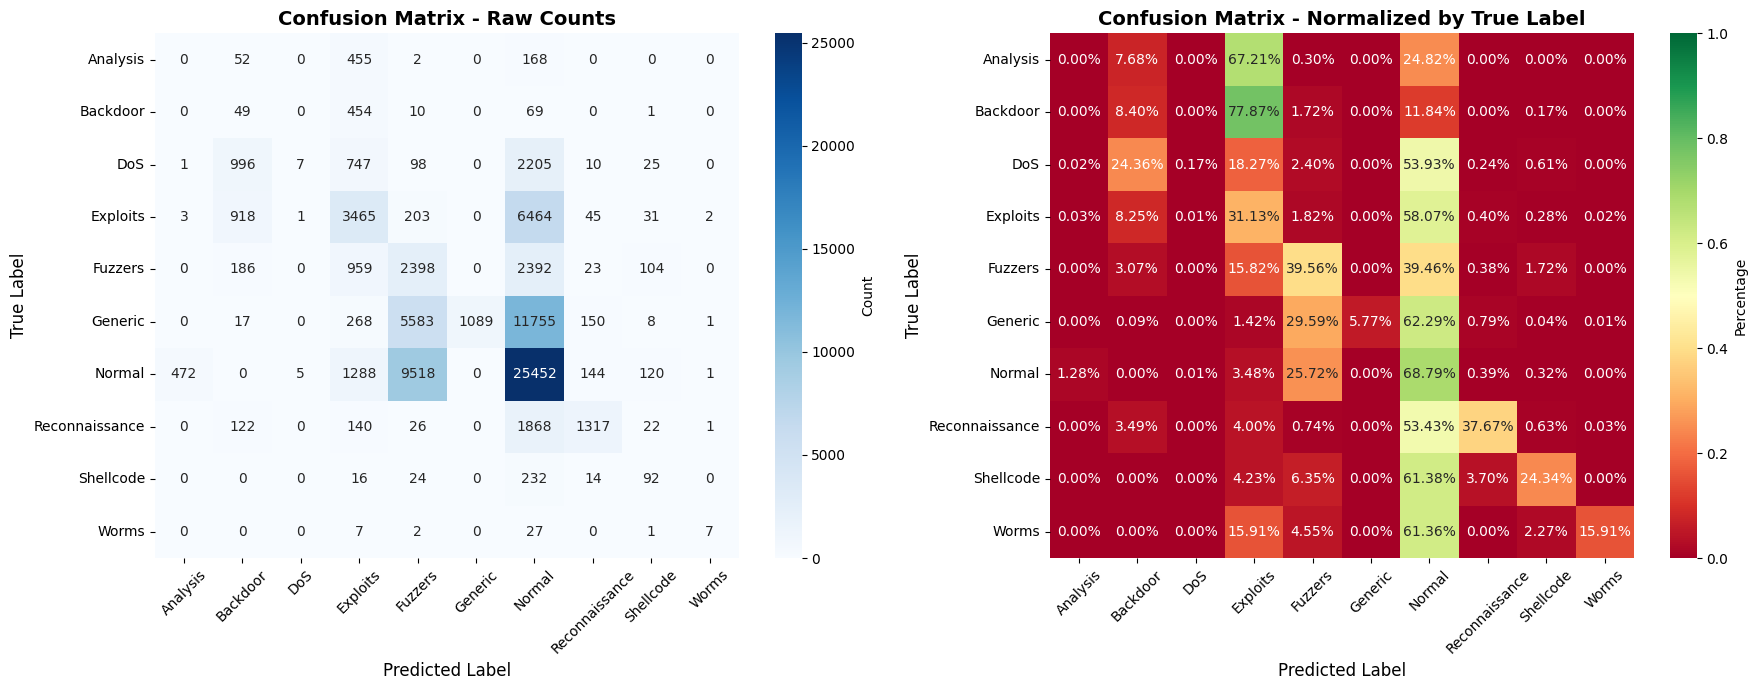

In [ ]:
# Multiclass confusion matrix

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
class_target_names = le.classes_
print(class_target_names)

class_cm = confusion_matrix(y_test_class_encoded, class_preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(class_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_target_names, yticklabels=class_target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
class_cm_normalized = class_cm.astype('float') / class_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(class_cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=class_target_names, yticklabels=class_target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# Per-class recall and F1-score

from sklearn.metrics import classification_report
class_target_names = le.classes_
print("Classification Report:\n",
      classification_report(y_test_class_encoded, class_preds, target_names=class_target_names))

Classification Report:
                 precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.02      0.08      0.03       583
           DoS       0.54      0.00      0.00      4089
      Exploits       0.44      0.31      0.37     11132
       Fuzzers       0.13      0.40      0.20      6062
       Generic       1.00      0.06      0.11     18871
        Normal       0.50      0.69      0.58     37000
Reconnaissance       0.77      0.38      0.51      3496
     Shellcode       0.23      0.24      0.24       378
         Worms       0.58      0.16      0.25        44

      accuracy                           0.41     82332
     macro avg       0.42      0.23      0.23     82332
  weighted avg       0.59      0.41      0.37     82332



# 2. Context-Aware Feature Semantics 

## 2.1 Group the dataset features into meaningful cybersecurity categories such as:

## 2.2 Attack Behavior Profiling

# 3. Misclassification and Security Error Analysis

## 3.1 Misclassification and Security Error Analysis

## 3.2 False Positive Security Interpretation

# 4. Trustworthy Security Interpretation (SOC Perspective)

## 4.1 Security-Centric Evaluation (Beyond Accuracy)